<a href="https://colab.research.google.com/github/ddoro1701/Assignment_01_Advanced_ML/blob/main/ML_Police_data_approach_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
from pathlib import Path
import zipfile
import json
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import PoissonRegressor, TweedieRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Hide noisy warnings
warnings.filterwarnings("ignore")

# Set paths
ZIP_PATH = Path("/content/Police_data.zip")
DATA_DIR = Path("/content/Police_data")
ARTIFACT_DIR = Path("/content/artifacts")

# Create folders
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract zip only once
if ZIP_PATH.exists() and not list(DATA_DIR.rglob("*.csv")):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

# Define helper metric
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

In [2]:
# Load only North Wales street files
paths = sorted(DATA_DIR.rglob("*-north-wales-street.csv"))
assert len(paths) > 0, "No North Wales CSV files found"

# Read only needed columns
use_cols = ["Month", "Latitude", "Longitude", "LSOA code", "LSOA name"]
raw = pd.concat((pd.read_csv(p, usecols=use_cols) for p in paths), ignore_index=True)

# Parse data types
raw["Month"] = pd.to_datetime(raw["Month"], format="%Y-%m", errors="coerce")
raw["Latitude"] = pd.to_numeric(raw["Latitude"], errors="coerce")
raw["Longitude"] = pd.to_numeric(raw["Longitude"], errors="coerce")

# Drop rows without valid time or area
raw = raw.dropna(subset=["Month", "LSOA code", "LSOA name"]).copy()

# Keep the assignment window
raw = raw[
    (raw["Month"] >= pd.Timestamp("2025-01-01")) &
    (raw["Month"] <= pd.Timestamp("2026-01-01"))
].copy()

print("Files found:", len(paths))
print("Rows loaded:", len(raw))
print("Months:", sorted(raw["Month"].dt.strftime("%Y-%m").unique().tolist()))
print("LSOAs:", raw["LSOA code"].nunique())
raw.head()

Files found: 13
Rows loaded: 67731
Months: ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']
LSOAs: 430


,Month,Longitude,Latitude,LSOA code,LSOA name
0,2025-01-01,-2.896347,53.094172,E01018339,Cheshire West and Chester 047A
1,2025-01-01,-2.896347,53.094172,E01018339,Cheshire West and Chester 047A
2,2025-01-01,-2.896347,53.094172,E01018339,Cheshire West and Chester 047A
3,2025-01-01,-2.896347,53.094172,E01018339,Cheshire West and Chester 047A
4,2025-01-01,-3.812998,53.318207,W01000132,Conwy 001A


In [3]:
# Build monthly crime counts per LSOA
monthly_counts = (
    raw.groupby(["Month", "LSOA code", "LSOA name"], as_index=False)
       .size()
       .rename(columns={"size": "crime_count"})
)

# Build a full LSOA x Month grid
all_months = pd.date_range(
    monthly_counts["Month"].min(),
    monthly_counts["Month"].max(),
    freq="MS"
)

lsoa_lookup = monthly_counts[["LSOA code", "LSOA name"]].drop_duplicates().reset_index(drop=True)

grid = (
    lsoa_lookup.assign(key=1)
    .merge(pd.DataFrame({"Month": all_months, "key": 1}), on="key")
    .drop(columns="key")
)

# Fill missing months with zero crimes
panel = (
    grid.merge(monthly_counts, on=["Month", "LSOA code", "LSOA name"], how="left")
        .sort_values(["LSOA code", "Month"])
        .reset_index(drop=True)
)

panel["crime_count"] = panel["crime_count"].fillna(0).astype(int)

# Add time features
panel["month_num"] = panel["Month"].dt.month.astype(int)
panel["year"] = panel["Month"].dt.year.astype(int)
panel["month_sin"] = np.sin(2 * np.pi * panel["month_num"] / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month_num"] / 12)

print("Panel shape:", panel.shape)
panel.head()

Panel shape: (5590, 8)


,LSOA code,LSOA name,Month,crime_count,month_num,year,month_sin,month_cos
0,E01018313,Cheshire West and Chester 031A,2025-01-01,0,1,2025,0.500000,8.660254e-01
1,E01018313,Cheshire West and Chester 031A,2025-02-01,0,2,2025,0.866025,5.000000e-01
2,E01018313,Cheshire West and Chester 031A,2025-03-01,0,3,2025,1.000000,6.123234e-17
3,E01018313,Cheshire West and Chester 031A,2025-04-01,0,4,2025,0.866025,-5.000000e-01
4,E01018313,Cheshire West and Chester 031A,2025-05-01,0,5,2025,0.500000,-8.660254e-01


In [4]:
# Sort before feature engineering
panel = panel.sort_values(["LSOA code", "Month"]).reset_index(drop=True)

# Group by area
g = panel.groupby("LSOA code", sort=False)

# Create lag features
panel["lag_1"] = g["crime_count"].shift(1)
panel["lag_2"] = g["crime_count"].shift(2)
panel["lag_3"] = g["crime_count"].shift(3)

# Create rolling means from past only
panel["roll_mean_3"] = g["crime_count"].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
)
panel["roll_mean_6"] = g["crime_count"].transform(
    lambda s: s.shift(1).rolling(window=6, min_periods=1).mean()
)

# Fill cold-start rows
for col in ["lag_1", "lag_2", "lag_3", "roll_mean_3", "roll_mean_6"]:
    panel[col] = panel[col].fillna(0)

# Create next-month target
panel["y_next"] = g["crime_count"].shift(-1)

# Keep rows with a known next month
data = panel.dropna(subset=["y_next"]).copy()
data["y_next"] = data["y_next"].astype(int)

print("Model data shape:", data.shape)
data.head()

Model data shape: (5160, 14)


,LSOA code,LSOA name,Month,crime_count,month_num,year,month_sin,month_cos,lag_1,lag_2,lag_3,roll_mean_3,roll_mean_6,y_next
0,E01018313,Cheshire West and Chester 031A,2025-01-01,0,1,2025,0.500000,8.660254e-01,0.0,0.0,0.0,0.0,0.0,0
1,E01018313,Cheshire West and Chester 031A,2025-02-01,0,2,2025,0.866025,5.000000e-01,0.0,0.0,0.0,0.0,0.0,0
2,E01018313,Cheshire West and Chester 031A,2025-03-01,0,3,2025,1.000000,6.123234e-17,0.0,0.0,0.0,0.0,0.0,0
3,E01018313,Cheshire West and Chester 031A,2025-04-01,0,4,2025,0.866025,-5.000000e-01,0.0,0.0,0.0,0.0,0.0,0
4,E01018313,Cheshire West and Chester 031A,2025-05-01,0,5,2025,0.500000,-8.660254e-01,0.0,0.0,0.0,0.0,0.0,0


In [5]:
# Define features
feature_cols = [
    "LSOA code",
    "month_num",
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "roll_mean_3",
    "roll_mean_6",
]

# Split by score month
# Rows from 2025-12 predict 2026-01
train_mask = (data["Month"] >= pd.Timestamp("2025-01-01")) & (data["Month"] <= pd.Timestamp("2025-10-01"))
val_mask = data["Month"] == pd.Timestamp("2025-11-01")
test_mask = data["Month"] == pd.Timestamp("2025-12-01")

X_train = data.loc[train_mask, feature_cols].copy()
y_train = data.loc[train_mask, "y_next"].copy()

X_val = data.loc[val_mask, feature_cols].copy()
y_val = data.loc[val_mask, "y_next"].copy()

X_test = data.loc[test_mask, feature_cols].copy()
y_test = data.loc[test_mask, "y_next"].copy()

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Test rows predict month:", "2026-01")

Train shape: (4300, 9)
Val shape: (430, 9)
Test shape: (430, 9)
Test rows predict month: 2026-01


In [6]:
# Score the naive baseline
# Baseline predicts next month = last month
val_pred_base = X_val["lag_1"].to_numpy(dtype=float)
test_pred_base = X_test["lag_1"].to_numpy(dtype=float)

baseline_results = pd.DataFrame([
    {
        "model": "naive_lag_1",
        "val_mae": mean_absolute_error(y_val, val_pred_base),
        "val_rmse": rmse(y_val, val_pred_base),
        "test_mae": mean_absolute_error(y_test, test_pred_base),
        "test_rmse": rmse(y_test, test_pred_base),
    }
])

baseline_results

,model,val_mae,val_rmse,test_mae,test_rmse
0,naive_lag_1,4.723256,6.763273,4.511628,6.508313


In [7]:
# Define sparse preprocessing
cat_cols = ["LSOA code"]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
        ]), cat_cols),
    ],
    sparse_threshold=1.0
)

# Define count models
model_specs = {
    "poisson_a_0.0001": PoissonRegressor(alpha=0.0001, max_iter=5000),
    "poisson_a_0.001": PoissonRegressor(alpha=0.001, max_iter=5000),
    "tweedie_p_1.1": TweedieRegressor(power=1.1, alpha=0.0001, link="log", max_iter=5000),
    "tweedie_p_1.3": TweedieRegressor(power=1.3, alpha=0.0001, link="log", max_iter=5000),
}

# Fit on train and score on val and test
rows = []
pipes = {}

for name, model in model_specs.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    val_pred = np.clip(pipe.predict(X_val), 0, None)
    test_pred = np.clip(pipe.predict(X_test), 0, None)

    rows.append({
        "model": name,
        "val_mae": mean_absolute_error(y_val, val_pred),
        "val_rmse": rmse(y_val, val_pred),
        "test_mae": mean_absolute_error(y_test, test_pred),
        "test_rmse": rmse(y_test, test_pred),
    })

    pipes[name] = pipe

model_results = pd.DataFrame(rows).sort_values(["val_mae", "val_rmse"]).reset_index(drop=True)

comparison = pd.concat([baseline_results, model_results], ignore_index=True)
comparison = comparison.sort_values(["val_mae", "val_rmse"]).reset_index(drop=True)

comparison

,model,val_mae,val_rmse,test_mae,test_rmse
0,tweedie_p_1.3,3.503082,5.076710,3.835641,6.528082
1,poisson_a_0.001,3.522431,5.374850,3.790248,6.016688
2,tweedie_p_1.1,3.548201,5.172729,3.834173,6.338632
3,poisson_a_0.0001,3.577651,5.240004,3.835145,6.231509
4,naive_lag_1,4.723256,6.763273,4.511628,6.508313


In [8]:
# Pick the best non-baseline model from validation
best_model_name = model_results.iloc[0]["model"]
best_model = model_specs[best_model_name]

# Refit on train + val for the final test score
train_val_mask = train_mask | val_mask
X_train_val = data.loc[train_val_mask, feature_cols].copy()
y_train_val = data.loc[train_val_mask, "y_next"].copy()

final_pipe = Pipeline([
    ("prep", preprocess),
    ("model", best_model)
])
final_pipe.fit(X_train_val, y_train_val)

# Score on test
final_test_pred = np.clip(final_pipe.predict(X_test), 0, None)

print("Best model:", best_model_name)
print("Final test MAE:", mean_absolute_error(y_test, final_test_pred))
print("Final test RMSE:", rmse(y_test, final_test_pred))

Best model: tweedie_p_1.3
Final test MAE: 3.78136319288201
Final test RMSE: 6.748319872633144


In [9]:
# Build test prediction table
test_predictions = data.loc[test_mask, ["Month", "LSOA code", "LSOA name", "crime_count", "y_next"]].copy()
test_predictions["forecast_month"] = test_predictions["Month"] + pd.DateOffset(months=1)
test_predictions["baseline_pred"] = X_test["lag_1"].to_numpy(dtype=float)
test_predictions["model_pred"] = final_test_pred
test_predictions = test_predictions.rename(columns={
    "crime_count": "current_month_count",
    "y_next": "actual_next_month_count"
})

# Save model and tables
joblib.dump(final_pipe, ARTIFACT_DIR / "model.joblib")
comparison.to_csv(ARTIFACT_DIR / "results.csv", index=False)
lsoa_lookup.to_csv(ARTIFACT_DIR / "lsoa_lookup.csv", index=False)
test_predictions.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)

# Save metadata
meta = {
    "best_model": best_model_name,
    "feature_cols": feature_cols,
    "train_months": ["2025-01", "2025-10"],
    "val_month": "2025-11",
    "test_month": "2025-12",
    "forecast_target_for_test": "2026-01",
    "target_name": "next_month_crime_count"
}

with open(ARTIFACT_DIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Artifacts saved to:", ARTIFACT_DIR)

Artifacts saved to: /content/artifacts


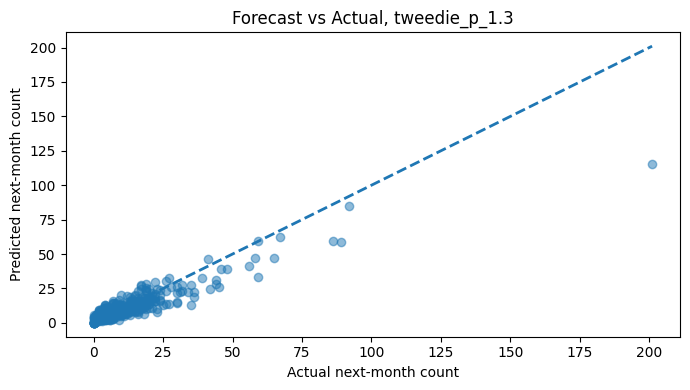

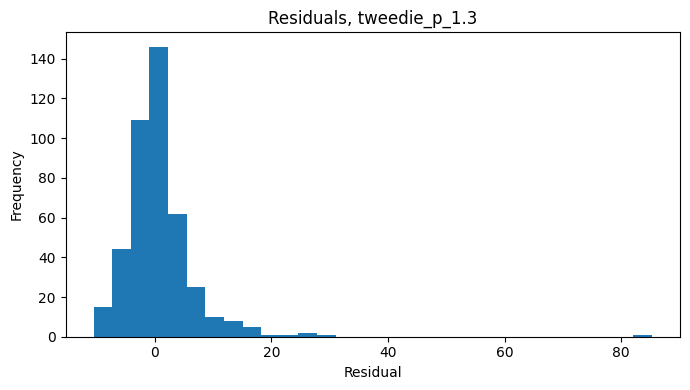

In [10]:
# Plot forecast vs actual
plt.figure(figsize=(7, 4))
plt.scatter(y_test, final_test_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2
)
plt.xlabel("Actual next-month count")
plt.ylabel("Predicted next-month count")
plt.title(f"Forecast vs Actual, {best_model_name}")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "forecast_vs_actual_test.png", dpi=200)
plt.show()

# Plot residuals
residuals = y_test.to_numpy() - final_test_pred

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title(f"Residuals, {best_model_name}")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "residuals_test.png", dpi=200)
plt.show()

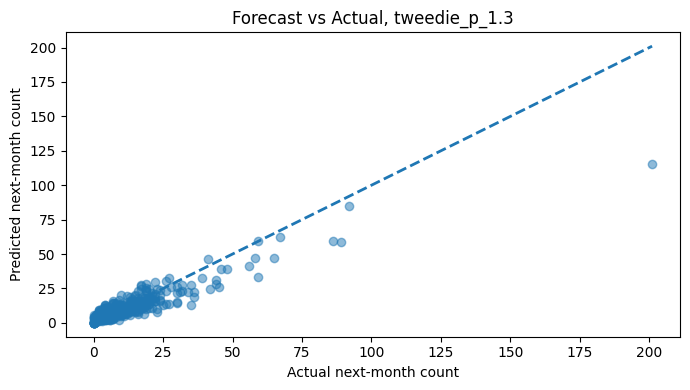

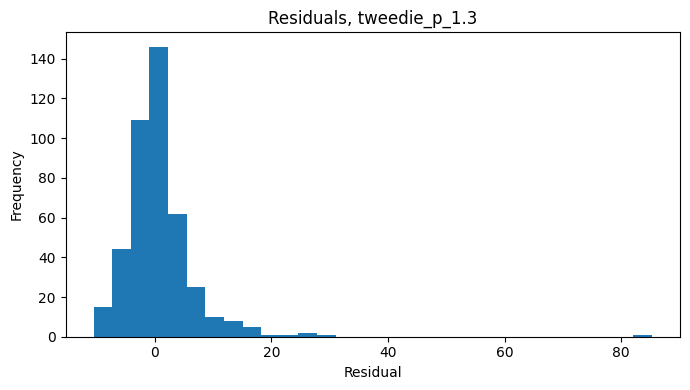

In [11]:
# Plot forecast vs actual
plt.figure(figsize=(7, 4))
plt.scatter(y_test, final_test_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2
)
plt.xlabel("Actual next-month count")
plt.ylabel("Predicted next-month count")
plt.title(f"Forecast vs Actual, {best_model_name}")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "forecast_vs_actual_test.png", dpi=200)
plt.show()

# Plot residuals
residuals = y_test.to_numpy() - final_test_pred

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title(f"Residuals, {best_model_name}")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "residuals_test.png", dpi=200)
plt.show()

In [12]:
# Build latest feature rows for the app
latest_month = panel["Month"].max()

latest_features = panel.loc[
    panel["Month"] == latest_month,
    ["Month", "LSOA name"] + feature_cols
].copy()

latest_features["forecast_month"] = latest_features["Month"] + pd.DateOffset(months=1)

# Save latest rows for the app
latest_features.to_csv(ARTIFACT_DIR / "latest_features.csv", index=False)

# Update metadata for the app
meta["latest_observed_month"] = str(latest_month.date())
meta["app_forecast_month"] = str((latest_month + pd.DateOffset(months=1)).date())

with open(ARTIFACT_DIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved:", ARTIFACT_DIR / "latest_features.csv")

Saved: /content/artifacts/latest_features.csv
